<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

resumes_orig = pd.read_csv("D:\datasets\hh_database.csv", sep = ';')

2. Первичный осмотр данных, выводы

In [4]:
print(resumes_orig.info())
resumes_orig.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 1987 Военный инженерный Кра...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


In [ ]:
cols_count_nulls = resumes_orig.isnull().sum()
print(cols_count_nulls[cols_count_nulls > 0].sort_values(ascending = False))

#пропуски в данных в процентах
nulls_percent = round(resumes_orig.isnull().mean()*100, 4)
print(nulls_percent[nulls_percent > 0].sort_values(ascending = False))

Опыт работы                        168
Последняя/нынешняя должность         2
Последнее/нынешнее место работы      1
dtype: int64
Опыт работы                        0.3755
Последняя/нынешняя должность       0.0045
Последнее/нынешнее место работы    0.0022
dtype: float64


## Выводы после первичного осмотра данных

**Общая информация:**
- 44 744 резюме, 12 признаков
- Все признаки имеют тип `object` — требуется преобразование

**Пропуски:**
- Опыт работы: 168 пропусков
- Последнее место работы: 1 пропуск
- Последняя должность: 2 пропуска
- Остальные признаки заполнены полностью

**Что требует преобразования:**
- ЗП : выделить сумму и валюту
- Пол, возраст : разделить на два признака
- Опыт работы : перевести в месяцы
- Образование и ВУЗ : выделить уровень образования
- Город, переезд, командировки : разбить на 3 признака
- Обновление резюме : перевести в datetime

**Гипотезы для анализа:**
- Зарплата зависит от образования, города и опыта
- Опыт коррелирует с возрастом
- Мобильность влияет на уровень зарплаты

**План:**
1. Преобразовать признаки
2. Очистить данные (пропуски, дубликаты, выбросы)
3. Провести визуальный анализ
4. Сделать выводы и рекомендации

# <center> Преобразования столбцов

Преобразование признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота
> Уровень образования находится в первых двух словах. 
После преобразования, столбец "Образование и Вуз" будет удален.


In [7]:
def get_education_level(education):
    if education.startswith('Неоконченное высшее'):
        return 'Неоконченное высшее'
    elif education.startswith('Среднее специальное'):
        return 'Среднее специальное'
    else:
        return education.split(' ')[0]
resumes = resumes_orig.copy()
resumes['Образование'] = resumes['Образование и ВУЗ'].apply(get_education_level)
resumes = resumes.drop('Образование и ВУЗ', axis = 1)

print(resumes['Образование'].unique())

['Неоконченное высшее' 'Высшее' 'Среднее специальное' 'Среднее']


К столбцу **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000

Создам два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.


In [8]:
def get_gender(gender):
    if gender.startswith('Муж'):
        return 'М'
    else:
        return 'Ж'
    
def get_age(row):
    parts = row.split(' , ')
    age_part = parts[1].strip()
    return int(age_part.split()[0])

resumes['Пол'] = resumes['Пол, возраст'].apply(get_gender)
resumes['Возраст'] = resumes['Пол, возраст'].apply(get_age)
resumes = resumes.drop('Пол, возраст', axis = 1)

print(resumes['Пол'].unique())
print(resumes['Возраст'].head())

['М' 'Ж']
0    39
1    60
2    36
3    38
4    26
Name: Возраст, dtype: int64


Признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца необходимо выделить общий опыт работы соискателя в месяцах, новый признак назову "Опыт в месяцах"

* В данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть 
* В данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN 
* Опыт работы может быть представлен только в годах или только месяцах(или и в годах и в месяцах)
> Учту эту особенность в своем коде

In [9]:
def get_work_exp(exp):
    if pd.isna(exp) or exp.startswith('Не указано'):
        return np.nan
    
    years = re.search(r'(\d+)\s*(?:лет|год)', exp)
    months = re.search(r'(\d+)\s*мес', exp)

    exp_months = 0
    if years:
        exp_months += int(years.group(1)) * 12
    if months:
        exp_months += int(months.group(1))
    return exp_months
resumes['Опыт в месяцах'] = resumes['Опыт работы'].apply(get_work_exp)
print(resumes.loc[:5, ['Опыт работы', 'Опыт в месяцах']])
resumes = resumes.drop('Опыт работы', axis = 1)

                                         Опыт работы  Опыт в месяцах
0  Опыт работы 16 лет 10 месяцев  Август 2010 — п...           202.0
1  Опыт работы 19 лет 5 месяцев  Январь 2000 — по...           233.0
2  Опыт работы 10 лет 3 месяца  Октябрь 2004 — Де...           123.0
3  Опыт работы 18 лет 9 месяцев  Август 2017 — Ап...           225.0
4  Опыт работы 5 лет 7 месяцев  Региональный мене...            67.0
5  Опыт работы 9 лет 9 месяцев  Технический специ...           117.0


Признак **"Город, переезд, командировки"**. Его текущий формат - это: **<Город → (метро) → готовность к переезду → готовность к командировкам.>**. 

Метро и города для переезда — необязательны, нас интересуют только:

Город — 4 категории: Москва, Санкт-Петербург, город-миллионник, другие.
Список миллионников:
['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград']

Готовность к переезду → True / False (любое упоминание без "не" считается готовностью)

Готовность к командировкам → True / False (если информации нет — False)

In [11]:
def get_city(val):
    val = val.split(' ')
    if val[0] == 'Москва':
        return 'Москва'
    elif val[0] == 'Санкт-Петербург':
        return 'Санкт-Петербург'
    elif val[0] in(['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']):
        return 'город-миллионик'
    else:
        return 'другие'

def ready_to_move(val):
    match = re.search(r',\s*(.+?)\s+(?:к переезду|переехать)', val)
    if not match:
        return False
    if 'не' in match.group(1).lower():
        return False
    return True

def ready_to_trips(val):
    match = re.search(r'(?:командировкам|командировке)', val)
    if not match:
        return False
    
    pos = match.start() 
    text_before = val[max(0, pos-25):pos]
    
    if 'не' in text_before:
        return False
    return True

resumes['Город'] = resumes['Город, переезд, командировки'].apply(get_city)
resumes['Готовность к переезду'] = resumes['Город, переезд, командировки'].apply(ready_to_move)
resumes['Готовность к командировкам'] = resumes['Город, переезд, командировки'].apply(ready_to_trips)
print(resumes.loc[:10, ['Город', 'Готовность к переезду', 'Готовность к командировкам', 'Город, переезд, командировки']])
resumes = resumes.drop('Город, переезд, командировки', axis = 1)




     Город  Готовность к переезду  Готовность к командировкам  \
0   другие                  False                       False   
1   другие                  False                        True   
2   другие                  False                       False   
3   другие                  False                        True   
4   Москва                  False                        True   
5   другие                  False                       False   
6   Москва                  False                        True   
7   Москва                   True                        True   
8   Москва                   True                        True   
9   Москва                  False                       False   
10  Москва                  False                        True   

                         Город, переезд, командировки  
0   Советск (Калининградская область) , не готов к...  
1   Королев , не готов к переезду , готов к редким...  
2   Тверь , не готова к переезду , не готова к ком.

Признаки **Занятость** и **График**

Исходные признаки содержали набор желаемых форматов занятости (полная, частичная, проектная, волонтёрство, стажировка) и графиков работы (полный день, сменный, гибкий, удалённая работа, вахтовый метод). Каждый соискатель мог указать несколько вариантов, что создавало множество уникальных комбинаций и усложняло анализ.

Для приведения данных к удобному формату я применила One-Hot Encoding: для каждой категории создала отдельный столбец-индикатор. Если категория была указана в резюме — ставится True, иначе — False.

В результате признаки «Занятость» и «График» были преобразованы в 10 бинарных столбцов, после чего исходные столбцы удалены.

In [ ]:
occupancy_list = resumes['Занятость'].str.get_dummies(sep=', ').astype(bool)
print(occupancy_list)
schedule_list = resumes['График'].str.get_dummies(sep = ', ').astype(bool)
print(schedule_list)


       волонтерство  полная занятость  проектная работа  стажировка  \
0             False              True              True       False   
1             False              True              True       False   
2             False              True             False       False   
3             False              True              True       False   
4             False              True             False       False   
...             ...               ...               ...         ...   
44739         False              True             False       False   
44740         False              True              True       False   
44741         False              True             False       False   
44742         False              True             False       False   
44743         False              True             False       False   

       частичная занятость  
0                     True  
1                     True  
2                    False  
3                     True  
4 


Исходный признак **«ЗП»** содержал сумму и валюту (рубли, доллары, евро, гривны и др.). Для корректного анализа я привела все зарплаты к единой валюте - рублям

Алгоритм действий:
* Из столбца «ЗП» выделила числовое значение и код валюты.
* Загрузила файл с курсами валют за период с 29.12.2017 по 05.12.2019 (данные с MDF.ru).
* Привела даты из «Обновления резюме» и файла курсов к единому формату.
* Для каждой записи нашла актуальный курс на дату обновления резюме.
* Для рубля курс приняла за 1 (close = 1, proportion = 1).
* Рассчитала зарплату в рублях по формуле: ЗП (руб) = (сумма × close) / proportion

В результате создан новый признак «ЗП (руб.)», все зарплаты приведены к рублям

In [13]:
exchange_rate = pd.read_csv("D:\datasets\ExchangeRates.csv")

exchange_rate['date'] = pd.to_datetime(exchange_rate['date'], format = '%d/%m/%y').dt.date
resumes['Обновление резюме'] = pd.to_datetime(resumes['Обновление резюме']).dt.date

currency_names = {
    'грн' : 'UAH',
    'бел' : 'BYN',
    'бел.руб.' : 'BYN',
    'сум' : 'UZS' 
}

resumes['Сумма зп'] = (resumes['ЗП'].str.split().str[0]).astype(float)
resumes['Валюта'] = resumes['ЗП'].str.split().str[1]

resumes['Валюта'] = resumes['Валюта'].map(currency_names).fillna(resumes['Валюта'])
print(resumes['Валюта'].unique()) 

currencies = exchange_rate[['date', 'close', 'currency', 'proportion']]
resumes_with_currencies = pd.merge(resumes, currencies, left_on = ['Обновление резюме', 'Валюта'], right_on = ['date', 'currency'], how = 'left')

resumes_with_currencies[['close', 'proportion']] = resumes_with_currencies[['close', 'proportion']].fillna(1)

resumes_with_currencies['ЗП (руб.)'] = (resumes_with_currencies['close'] * resumes_with_currencies['Сумма зп']) / resumes_with_currencies['proportion']
print(
    resumes_with_currencies.loc[
        resumes_with_currencies['Валюта'] != 'руб.', 
        ['Ищет работу на должность:', 'Сумма зп', 'Валюта', 'ЗП (руб.)']
    ].head(5)
)
print(resumes_with_currencies.loc[4:8, ['Ищет работу на должность:', 'Сумма зп', 'Валюта', 'ЗП (руб.)']])









C:\Users\Admin\AppData\Local\Temp\ipykernel_12000\944356396.py:4: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  resumes['Обновление резюме'] = pd.to_datetime(resumes['Обновление резюме']).dt.date


['руб.' 'BYN' 'KZT' 'EUR' 'USD' 'грн.' 'UZS' 'KGS' 'AZN']
                             Ищет работу на должность:  Сумма зп Валюта  \
30                                            Engineer    3000.0    BYN   
81            Системный администратор, веб-программист  160000.0    KZT   
126  Программист, Инженер-системотехник, Водитель, ...  217000.0    KZT   
145                     Координатор проектов, редактор    2000.0    EUR   
147              Разработчик ПО, аналитик, консультант    5500.0    USD   

      ЗП (руб.)  
30    91896.000  
81    26988.800  
126   36922.767  
145  146177.600  
147  355736.700  
           Ищет работу на должность:  Сумма зп Валюта  ЗП (руб.)
4  Региональный менеджер по продажам  140000.0   руб.   140000.0
5             Технический специалист   25000.0   руб.    25000.0
6           Руководитель ИТ-проектов  250000.0   руб.   250000.0
7                     Инженер АСУ ТП   70000.0   руб.    70000.0
8                            Ревизор   65000.0   руб.    6

# <center> Очистка данных

In [14]:
dupl_columns = list(resumes.columns)
dupl_resumes = resumes[resumes.duplicated(subset = dupl_columns, keep = False)]
dupl_count = dupl_resumes.shape[0]
print(f'Количество полных дубликатов уже существующих резюме - {dupl_count}. Удалим дубли, оставляя первые вхождения')
resumes_clean = resumes_with_currencies.copy()
resumes_clean = resumes_clean.drop_duplicates(keep = 'first')

check_dupls_count = resumes_clean[resumes_clean.duplicated(subset = dupl_columns, keep = False)].shape[0]
print(f'Количество дублей после удаления- {check_dupls_count}')

Количество полных дубликатов уже существующих резюме - 318. Удалим дубли, оставляя первые вхождения
Количество дублей после удаления- 0


In [15]:
exp_median = resumes_clean['Опыт в месяцах'].median()
resumes_clean['Опыт в месяцах'] = resumes_clean['Опыт в месяцах'].fillna(exp_median)
print(f"Медианное значение опыта - {exp_median}")
print(f"До удаления: {len(resumes_clean)} строк")
resumes_clean = resumes_clean.dropna(subset=['Последнее/нынешнее место работы'])
resumes_clean = resumes_clean.dropna(subset=['Последняя/нынешняя должность'])

print(f"Осталось строк: {len(resumes_clean)}")

Медианное значение опыта - 100.0
До удаления: 44585 строк
Осталось строк: 44583


Устраним выбросы - удалим записи с зп менее тысячи или более миллиона рублей.

Устраним аномалии - Опыт в годах не должен превышать возраст соискателя

In [17]:
resumes_clean = resumes_clean[resumes_clean['ЗП (руб.)'] <= 1000000]
resumes_clean = resumes_clean[resumes_clean['ЗП (руб.)'] >= 1000]

resumes_clean['Опыт в годах'] = resumes_clean['Опыт в месяцах'] / 12

anomalies = resumes_clean[resumes_clean['Опыт в годах'] > resumes_clean['Возраст']]
print(f"\nНайдено аномалий - {len(anomalies)}")
if len(anomalies) > 0:
    print("\nПримеры аномальных записей:")
    print(anomalies[['Возраст', 'Опыт в годах', 'Опыт в месяцах']].head(5))

resumes_clean = resumes_clean[resumes_clean['Опыт в годах'] <= resumes_clean['Возраст']]
resumes = resumes_clean.drop(columns=['Опыт в годах'])


Найдено аномалий - 32

Примеры аномальных записей:
      Возраст  Опыт в годах  Опыт в месяцах
2098       26   2017.916667         24215.0
3280       21   2019.166667         24230.0
3813       18     18.916667           227.0
4535       18     22.583333           271.0
8278       20   2016.916667         24203.0


# <center> Визуализации и исследование зависимостей

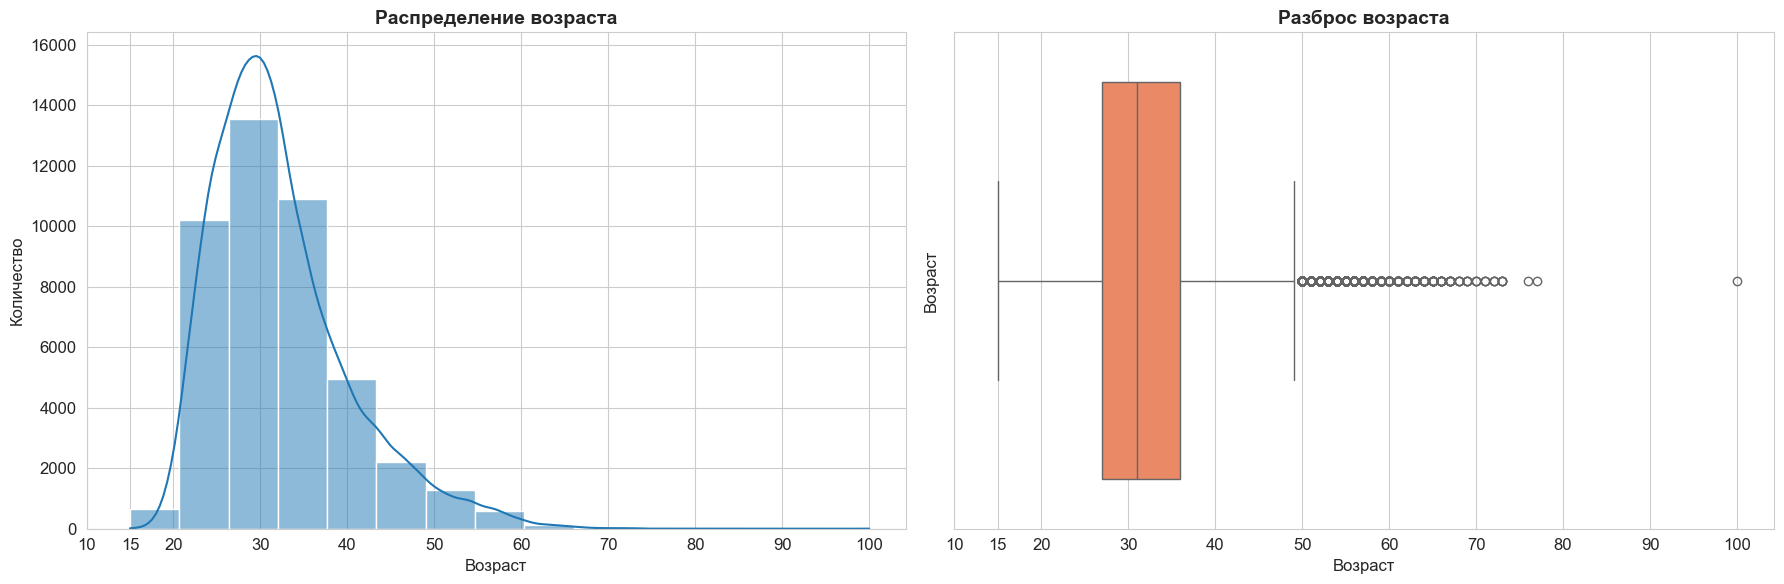

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(resumes['Возраст'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Распределение возраста', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество', fontsize=12)


axes[0].set_xticks(range(10, 91, 10))
ticks = list(axes[0].get_xticks())
ticks.extend([resumes['Возраст'].min(), resumes['Возраст'].max()])
ticks = sorted(set(ticks))
axes[0].set_xticks(ticks)


sns.boxplot(x=resumes['Возраст'], color='coral', ax=axes[1])
axes[1].set_title('Разброс возраста', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Возраст', fontsize=12)
axes[1].set_xticks(range(10, 91, 10))
ticks = list(axes[1].get_xticks())
ticks.extend([resumes['Возраст'].min(), resumes['Возраст'].max()])
ticks = sorted(set(ticks))
axes[1].set_xticks(ticks)


plt.tight_layout()
plt.show()


**Большинство(50%) соискателей находятся в возрасте** *от 24 до 36 лет (IQR)*
Минимальный возраст - 14 лет, максимальный ~ 76

Медианный возраст ~ 32. 

**Выявлен соискатель с возрастом 100 лет** - это явная **ошибка ввода или технический сбой**
Данную запись рекомендуется исключить из дальнейшего анализа, чтобы не искажать статистику и визуализацию

РЕКОМЕНДАЦИИ :
- настроить валидацию поля "Возраст" во избежание ошибок ввода
- сосредоточить рекрутинговые усилия на возрастной группе 22–35 лет, так как на неё приходится наибольшая концентрация резюме

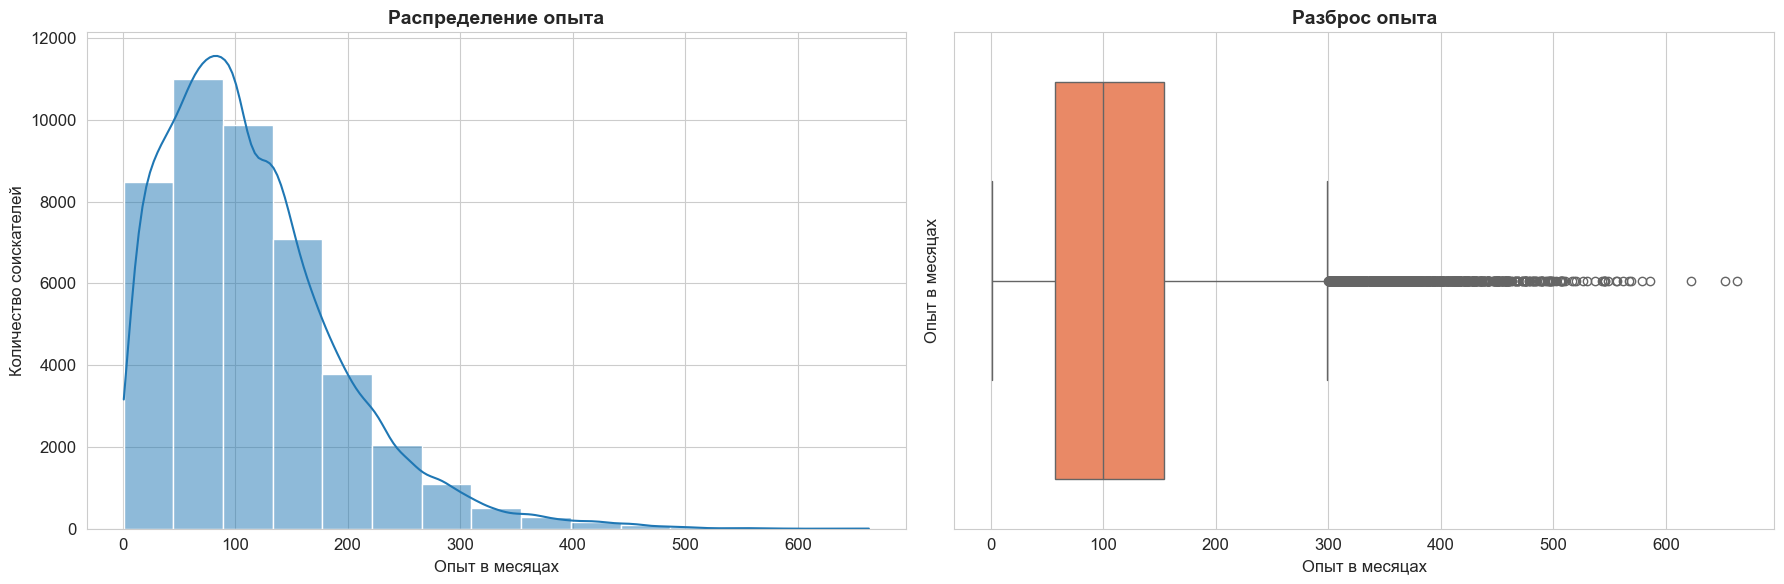

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(resumes['Опыт в месяцах'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Распределение опыта', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество соискателей', fontsize=12)

sns.boxplot(x=resumes['Опыт в месяцах'], color='coral', ax=axes[1])
axes[1].set_title('Разброс опыта', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Опыт в месяцах', fontsize=12)

plt.tight_layout()
plt.show()

Гистограмма демонстрирует правостороннюю асимметрию: **основной пик приходится** *на 7–8 лет*,
после чего распределение постепенно сглаживается в сторону увеличения опыта

Основной диапазон (IQR) от *4 до 12 лет.* Это значит, что 50% всех соискателей сосредоточены в этом интервале - наиболее стабильная и репрезентативная часть выборки.
В данных присутствуют резюме **без опыта работы**. 
Имеются соискатели **с опытом от 15 до 50 лет**. Это могут быть как реально опытные кадры (Сеньоры, руководители), так и потенциальные ошибки ввода. Эти значения формируют «правый хвост» распределения

РЕКОМЕНДАЦИИ:
- в выборке достаточно соискателей с нулевым опытом, можно формировать стажёрские программы и позиции начального уровня
- значения опыта 30–50 лет стоит проверить дополнительно — возможны ошибки ввода

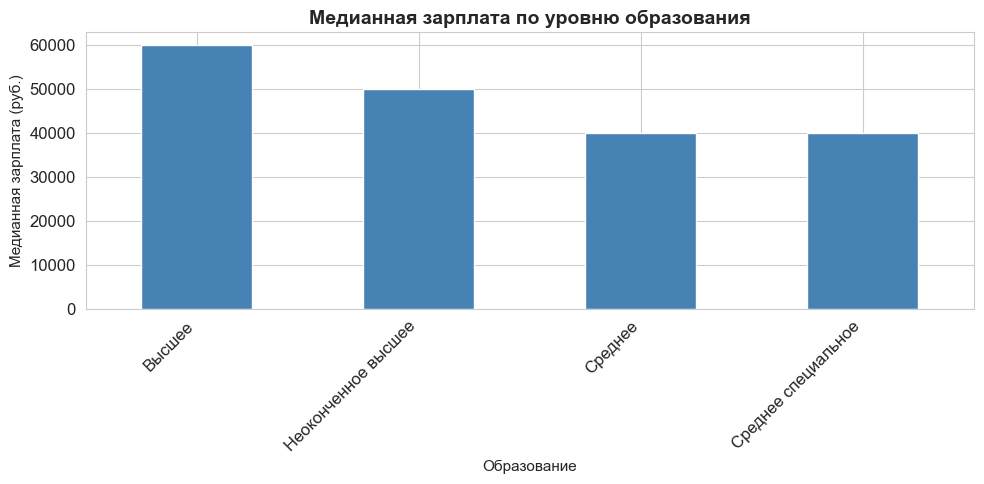

Образование
Высшее                 60000.0
Неоконченное высшее    50000.0
Среднее                40000.0
Среднее специальное    40000.0
Name: ЗП (руб.), dtype: float64


In [24]:
df = resumes_with_currencies[resumes_with_currencies['ЗП (руб.)'] < 1000000]
median_salary = df.groupby('Образование')['ЗП (руб.)'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
median_salary.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)

ax.set_title('Медианная зарплата по уровню образования', fontsize=14, fontweight='bold')
ax.set_xlabel('Образование', fontsize=11)
ax.set_ylabel('Медианная зарплата (руб.)', fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(median_salary)

**Наибольшая желаемая зарплата** у специалистов с *высшим образованием*, **наименьшая** - *со средним*.
Можно наблюдать положительную связь между уровнем и зарплатой.
Уровень образования важен - чем выше образование, тем выше медианная желаемая зарплата.Но это не единственный фактор (влияют опыт, профессия, регион)

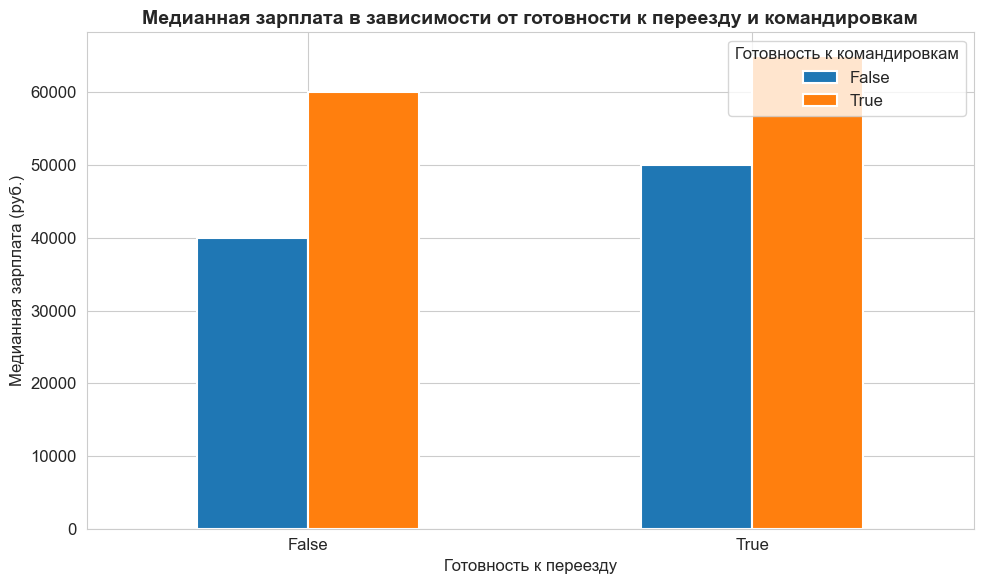

In [25]:
df = resumes_with_currencies[resumes_with_currencies['ЗП (руб.)'] < 1000000]
grouped = df.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб.)'].median().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
grouped.plot(kind='bar', ax=ax, edgecolor='white', linewidth=1.5)

ax.set_title('Медианная зарплата в зависимости от готовности к переезду и командировкам', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Готовность к переезду', fontsize=12)
ax.set_ylabel('Медианная зарплата (руб.)', fontsize=12)
ax.legend(title='Готовность к командировкам')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Максимальная медианная зарплата** у готовых и к переезду, и к командировкам

**Минимальная медианная зарплата** у неготовых ни к переезду, ни к командировкам

Мобильность соискателя **положительно коррелирует** с уровнем желаемой зарплаты. Наиболее ценными на рынке являются кандидаты, готовые работать в любых условиях.

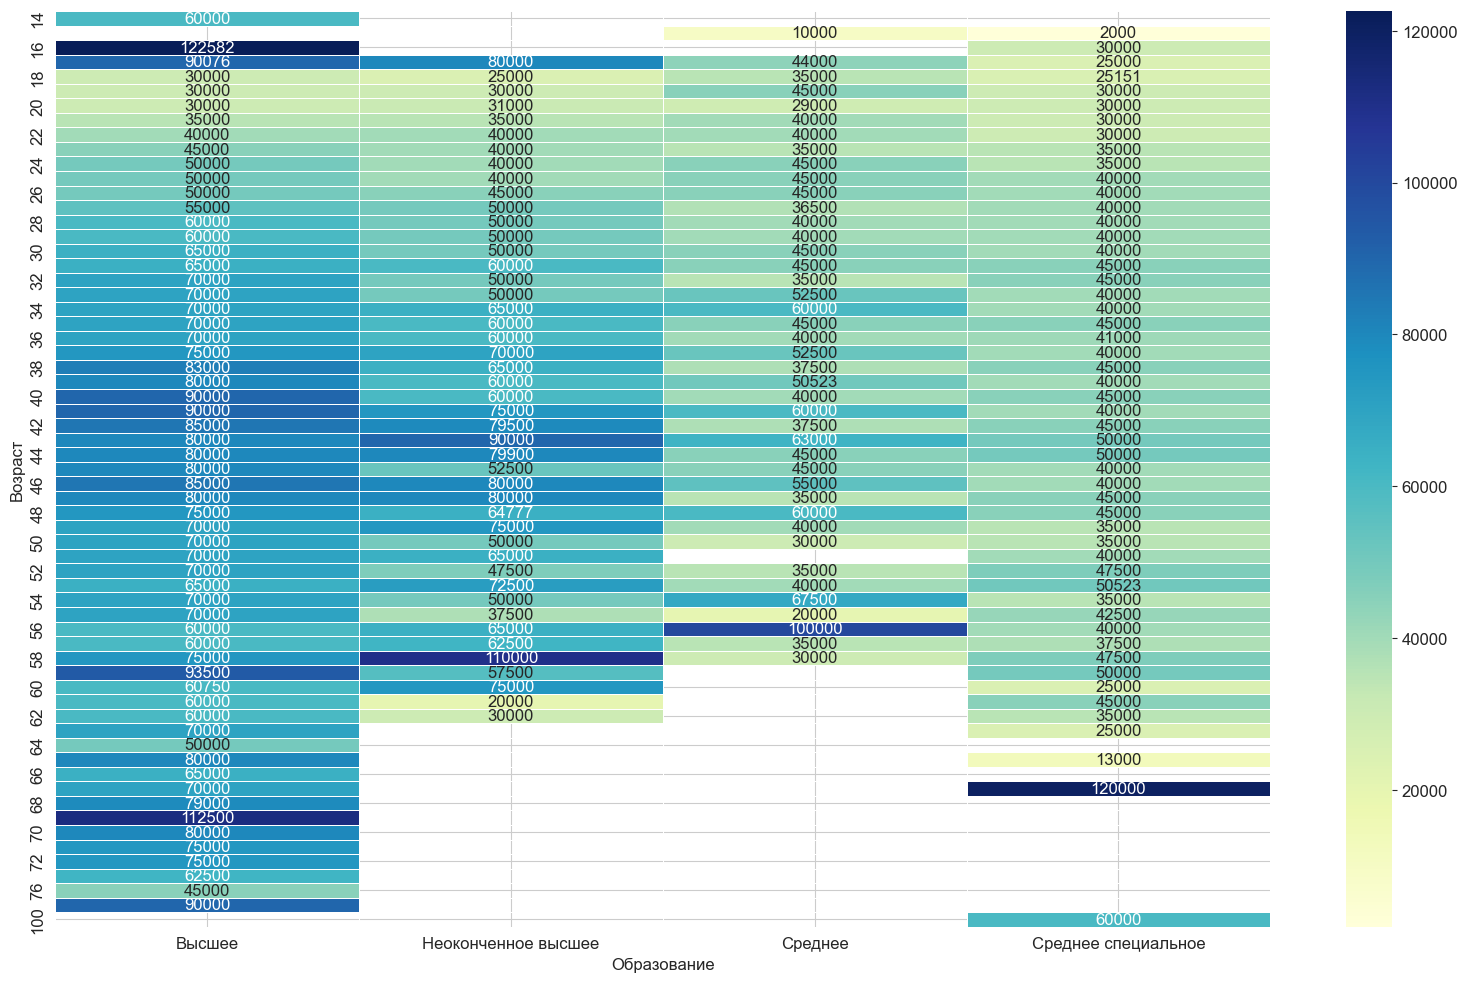

In [ ]:
df = resumes_with_currencies[resumes_with_currencies['ЗП (руб.)'] < 1000000].copy()

pivot = df.pivot_table(
    values='ЗП (руб.)',
    index='Возраст',
    columns='Образование',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', 
            linewidths=0.5, ax=ax)
plt.tight_layout()
plt.show()



### Зависимость зарплаты от возраста и образования
Тепловая карта показала, что возраст и уровень образования совместно влияют на зарплату — причём этот эффект усиливается с возрастом.

Ключевые наблюдения:
* Выбросы: обнаружен 16-летний соискатель с зарплатными ожиданиями 120 000 ₽ — вероятно, ошибка ввода или тестовое резюме.
*бСоискатели 60+ лет — вне зависимости от образования, ожидают зарплату выше 100 000 ₽. Вероятно, их многолетний опыт перевешивает формальный уровень образования.
* Основная группа (30–40 лет): соискатели с высшим образованием в среднем зарабатывают на 30–40 тыс. руб. больше, чем их коллеги со средним специальным образованием.

**Возраст и образование работают в связке**: в молодости разница между уровнями образования минимальна, но к 30–40 годам она становится наиболее заметной. После 60 лет на первый план выходит опыт, который частично нивелирует значение образования.